# 质量动量因子

区别于简单涨幅排名，本因子将趋势强度与趋势稳定性结合：`score = annual_ret × R²`。

- **示例代码版**：使用 26 个收盘价、`1 → 2` 线性权重，并严格保留原示例的 `np.polyfit` 和 R² 口径。
- **63 日半衰期版**：使用指数观测权重、标准加权最小二乘和加权均值 R²，作为对照。

因子包含当日收盘价。`analyze_factor` 以 t+1 及之后的收益评价 t 日因子，因此不会使用同日收益产生前视。

In [1]:
# 获取数据
%reload_ext autoreload
%autoreload 2
import sys

sys.path.append(r'C:\Users\20561\Desktop\策略')
from my_utils.fun import read_day_data
from 因子回测.alpha import analyze_factor
import polars as pl
import numpy as np
import datetime as dt

start_date = dt.date(2021, 1, 1)
end_date = dt.date(2026, 1, 1)
window = 26
annualization = 250
half_life = 63.0

# 预热数据只用于形成分析首日的完整 26 日价格窗口。
data_start_date = start_date - dt.timedelta(days=60)
stock_data = read_day_data(
    start_date=data_start_date,
    end_date=end_date,
    fields=['trading_date', 'code', 'close', 'pre_close'],
)


In [2]:
def quality_momentum_weights(
    window: int,
    mode: str,
    half_life: float = 63.0,
) -> np.ndarray:
    """生成示例版线性权重或标准半衰期观测权重。"""
    if window < 2:
        raise ValueError('window 必须大于等于 2')
    if half_life <= 0:
        raise ValueError('half_life 必须大于 0')
    if mode == 'example':
        return np.linspace(1.0, 2.0, window)
    if mode == 'halflife':
        age = np.arange(window - 1, -1, -1, dtype=float)
        return 0.5 ** (age / half_life)
    raise ValueError("mode 必须是 'example' 或 'halflife'")


def calc_momentum_score(
    prices,
    mode: str = 'example',
    annualization: int = 250,
    half_life: float = 63.0,
) -> tuple[float, float, float]:
    """计算一个价格窗口的年化趋势收益、R² 与质量动量得分。"""
    prices = np.asarray(prices, dtype=float)
    if prices.ndim != 1:
        raise ValueError('prices 必须是一维价格序列')

    weights = quality_momentum_weights(len(prices), mode, half_life)
    if not np.isfinite(prices).all() or np.any(prices <= 0):
        return np.nan, np.nan, np.nan

    y = np.log(prices)
    if np.ptp(y) <= 1e-12:
        return 0.0, 0.0, 0.0

    x = np.arange(len(y), dtype=float)
    # np.polyfit 的 w 会最小化 (w × residual)²；半衰期版传入平方根以得到标准 WLS。
    fit_weights = weights if mode == 'example' else np.sqrt(weights)
    slope, intercept = np.polyfit(x, y, deg=1, w=fit_weights)
    annual_ret = np.expm1(slope * annualization)
    y_fit = np.polyval([slope, intercept], x)

    # 示例版沿用原始的非加权中心；半衰期版使用与回归一致的加权中心。
    center = y.mean() if mode == 'example' else np.average(y, weights=weights)
    ss_res = np.sum(weights * (y - y_fit) ** 2)
    ss_tot = np.sum(weights * (y - center) ** 2)
    r2 = 0.0 if ss_tot <= 1e-10 else 1.0 - ss_res / ss_tot
    if mode == 'halflife':
        r2 = float(np.clip(r2, 0.0, 1.0))

    return float(annual_ret), float(r2), float(annual_ret * r2)


def _calculate_momentum_windows(
    price_windows: np.ndarray,
    mode: str,
    annualization: int,
    half_life: float,
) -> np.ndarray:
    """批量计算同一股票的全部滚动窗口，避免逐行 Python 回调。"""
    window_size = price_windows.shape[1]
    metrics = np.full((len(price_windows), 3), np.nan, dtype=float)
    valid = np.isfinite(price_windows).all(axis=1) & (price_windows > 0).all(axis=1)
    if not np.any(valid):
        return metrics

    y = np.log(price_windows[valid])
    x = np.arange(window_size, dtype=float)
    weights = quality_momentum_weights(window_size, mode, half_life)
    # 示例版与 np.polyfit(w=weights) 等价，即回归目标的观测权重为 weights²。
    regression_weights = weights**2 if mode == 'example' else weights
    weight_sum = regression_weights.sum()
    x_mean = np.sum(regression_weights * x) / weight_sum
    x_centered = x - x_mean
    denominator = np.sum(regression_weights * x_centered**2)

    slopes = np.sum(y * (regression_weights * x_centered), axis=1) / denominator
    intercepts = (
        np.sum(y * regression_weights, axis=1) / weight_sum - slopes * x_mean
    )
    fitted = slopes[:, None] * x + intercepts[:, None]
    annual_ret = np.expm1(slopes * annualization)

    centers = (
        y.mean(axis=1)
        if mode == 'example'
        else np.sum(y * weights, axis=1) / weights.sum()
    )
    ss_res = np.sum(weights * (y - fitted) ** 2, axis=1)
    ss_tot = np.sum(weights * (y - centers[:, None]) ** 2, axis=1)
    r2 = np.zeros(len(y), dtype=float)
    non_constant = ss_tot > 1e-10
    r2[non_constant] = 1.0 - ss_res[non_constant] / ss_tot[non_constant]

    # 常数价格窗口的斜率是浮点噪音，统一归零以保证输出可解释。
    constant = np.ptp(y, axis=1) <= 1e-12
    annual_ret[constant] = 0.0
    r2[constant] = 0.0
    if mode == 'halflife':
        r2 = np.clip(r2, 0.0, 1.0)

    metrics[valid] = np.column_stack((annual_ret, r2, annual_ret * r2))
    return metrics


def add_quality_momentum_factors(
    data: pl.DataFrame,
    window: int = 26,
    annualization: int = 250,
    half_life: float = 63.0,
) -> pl.DataFrame:
    """按股票追加示例版和半衰期版质量动量因子。"""
    required = {'code', 'trading_date', 'close'}
    missing = sorted(required.difference(data.columns))
    if missing:
        raise ValueError('缺少必要列: ' + ', '.join(missing))
    quality_momentum_weights(window, 'example', half_life)

    mode_columns = {
        'example': ('momentum_annual_ret', 'momentum_r2', 'momentum_score'),
        'halflife': (
            'momentum_annual_ret_halflife',
            'momentum_r2_halflife',
            'momentum_score_halflife',
        ),
    }

    def add_group(group: pl.DataFrame) -> pl.DataFrame:
        group = group.sort('trading_date')
        output = {
            column: np.full(group.height, np.nan, dtype=float)
            for columns in mode_columns.values()
            for column in columns
        }
        if group.height >= window:
            price_windows = np.lib.stride_tricks.sliding_window_view(
                group['close'].to_numpy(), window_shape=window
            )
            for mode, columns in mode_columns.items():
                metrics = _calculate_momentum_windows(
                    price_windows, mode, annualization, half_life
                )
                for metric_index, column in enumerate(columns):
                    output[column][window - 1:] = metrics[:, metric_index]

        return group.with_columns(
            [pl.Series(column, values) for column, values in output.items()]
        )

    factor_columns = [
        column for columns in mode_columns.values() for column in columns
    ]
    return (
        data.sort('code', 'trading_date')
        .group_by('code', maintain_order=True)
        .map_groups(add_group)
        .with_columns([pl.col(column).fill_nan(None) for column in factor_columns])
        .sort('code', 'trading_date')
    )


stock_data = add_quality_momentum_factors(
    stock_data,
    window=window,
    annualization=annualization,
    half_life=half_life,
)

# daily_ret[t] 表示 t-1 收盘到 t 收盘；analyze_factor 从 t+1 开始评价 t 日因子。
analysis_data = (
    stock_data.with_columns(
        (pl.col('close') / pl.col('pre_close') - 1).alias('daily_ret')
    )
    .filter(pl.col('trading_date').is_between(start_date, end_date))
    .select(
        'trading_date',
        'code',
        'momentum_annual_ret',
        'momentum_r2',
        'momentum_score',
        'momentum_annual_ret_halflife',
        'momentum_r2_halflife',
        'momentum_score_halflife',
        'daily_ret',
    )
    .drop_nulls(['momentum_score', 'momentum_score_halflife', 'daily_ret'])
    .filter(
        pl.col('momentum_score').is_finite()
        & pl.col('momentum_score_halflife').is_finite()
        & pl.col('daily_ret').is_finite()
    )
    .with_columns(
        pl.col('daily_ret').mean().over('trading_date').alias('benchmark_ret')
    )
)

analysis_data.head()


trading_date,code,momentum_annual_ret,momentum_r2,momentum_score,momentum_annual_ret_halflife,momentum_r2_halflife,momentum_score_halflife,daily_ret,benchmark_ret
date,str,f64,f64,f64,f64,f64,f64,f64,f64
2021-01-04,"""SHSE.600000""",-0.477453,0.769195,-0.367254,-0.514666,0.783275,-0.403125,0.001033,0.014412
2021-01-05,"""SHSE.600000""",-0.433152,0.69806,-0.302366,-0.482753,0.720299,-0.347726,-0.001032,-0.000934
2021-01-06,"""SHSE.600000""",-0.366422,0.551353,-0.202028,-0.441955,0.59968,-0.265031,0.014463,-0.012799
2021-01-07,"""SHSE.600000""",-0.276748,0.393666,-0.108946,-0.367582,0.459408,-0.16887,-0.001018,-0.0255
2021-01-08,"""SHSE.600000""",-0.178637,0.227079,-0.040565,-0.283175,0.305256,-0.086441,0.002039,-0.000938



===== 示例代码版：momentum_score =====


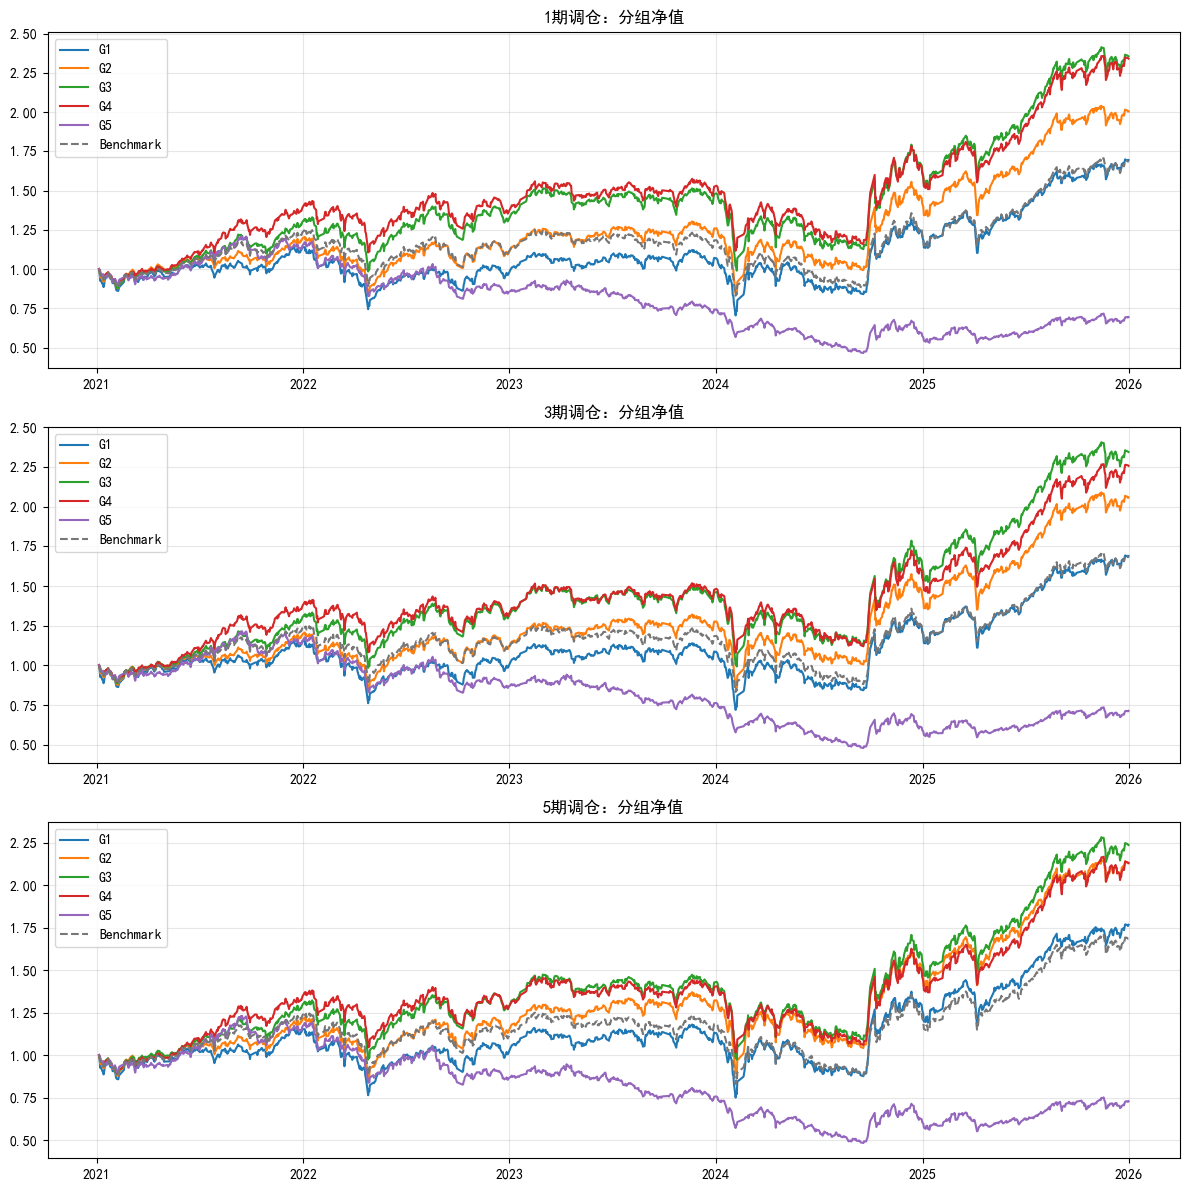

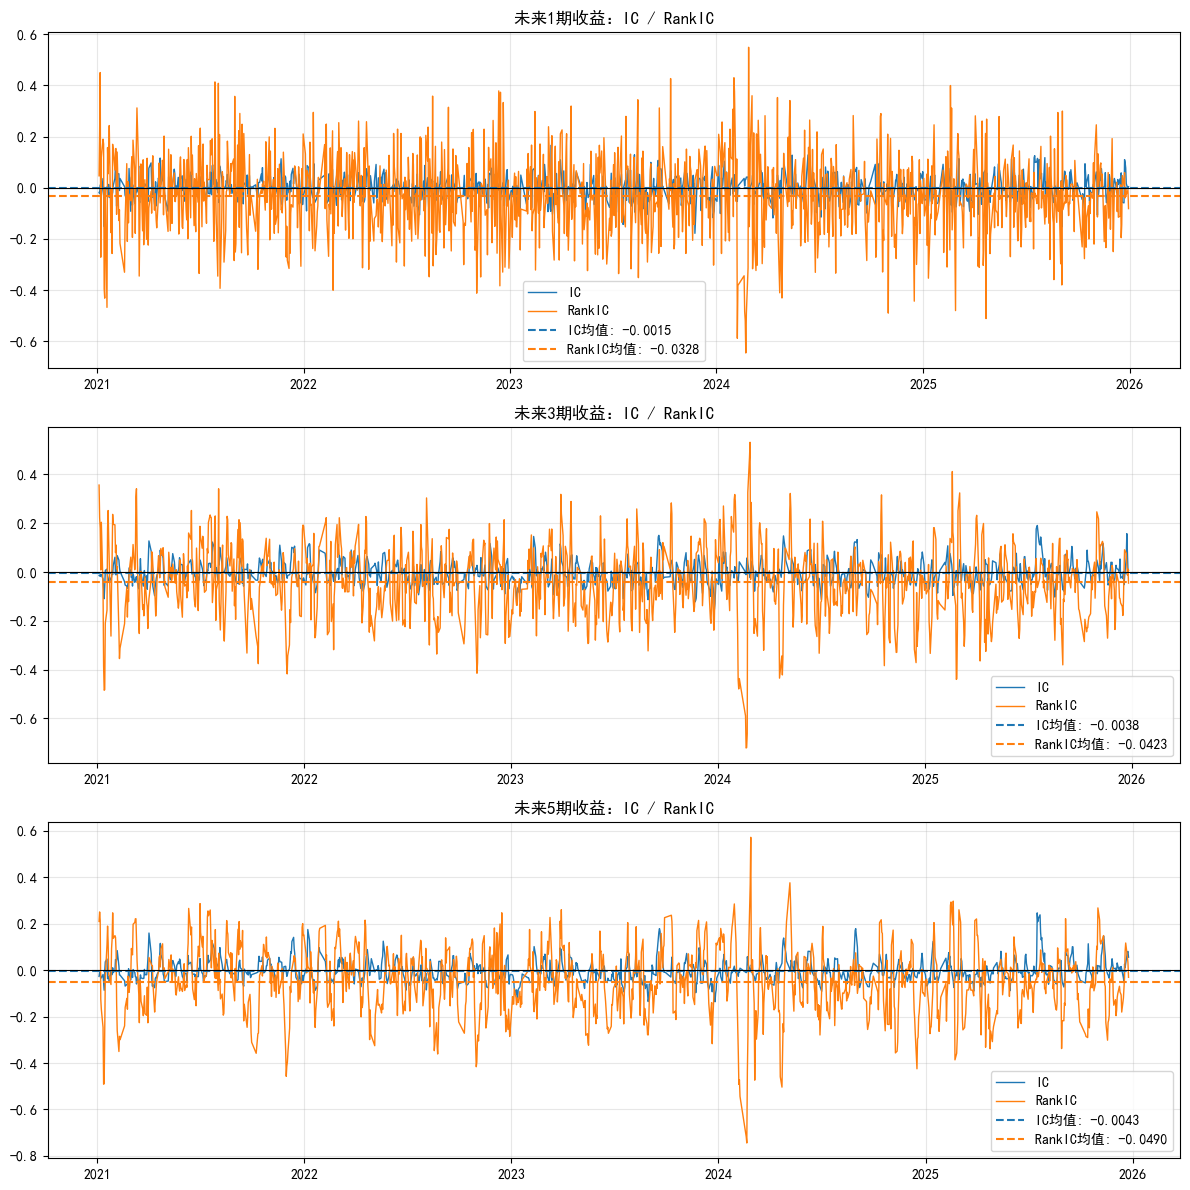

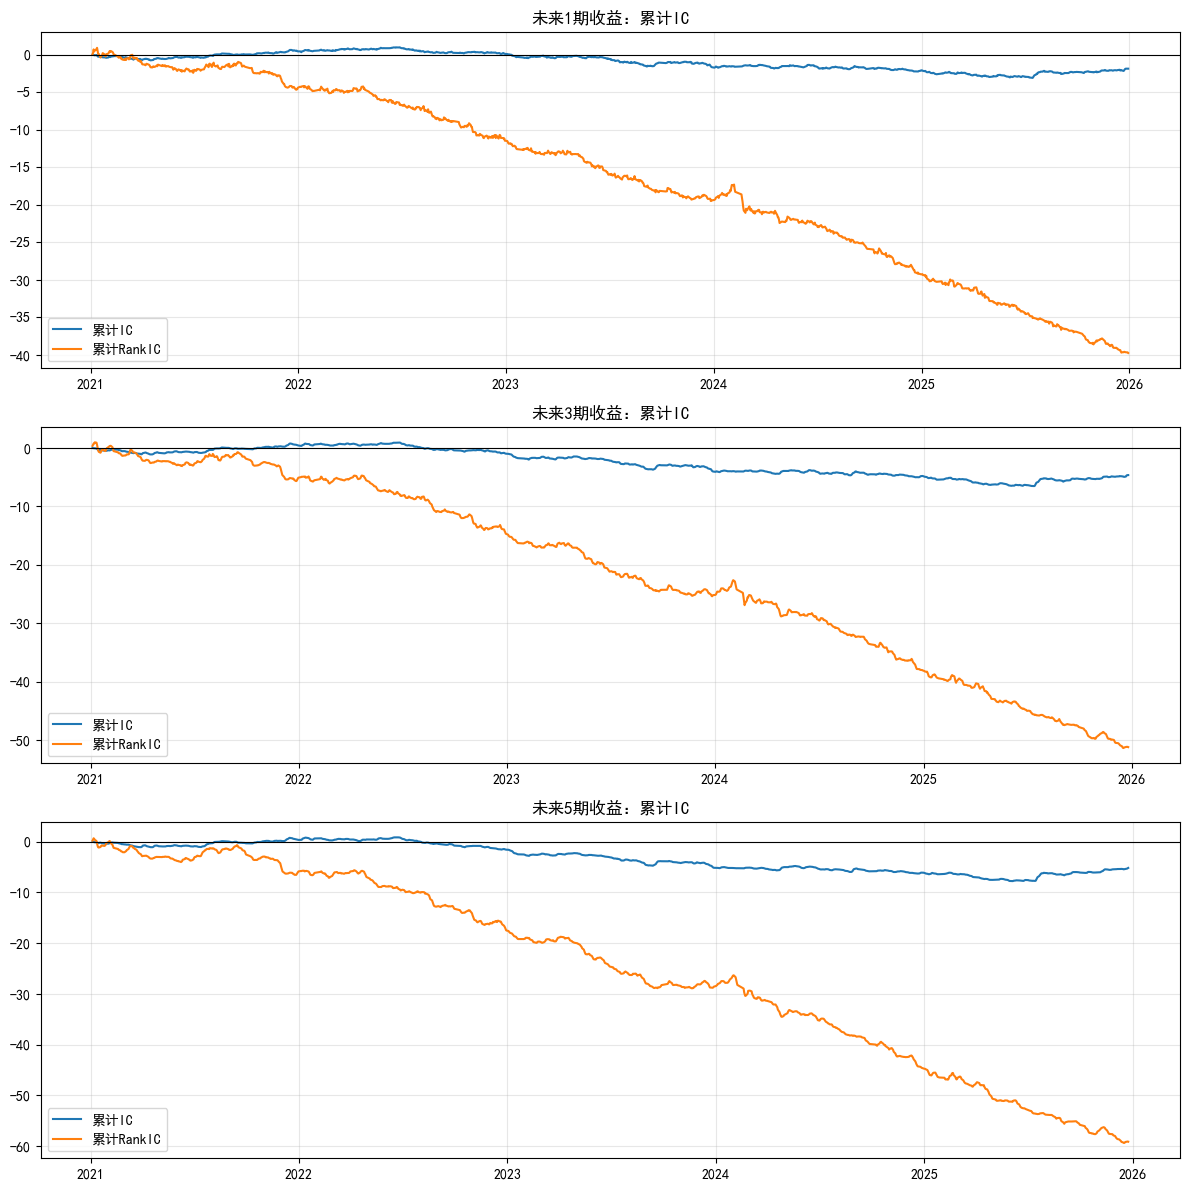


===== 63日半衰期版：momentum_score_halflife =====


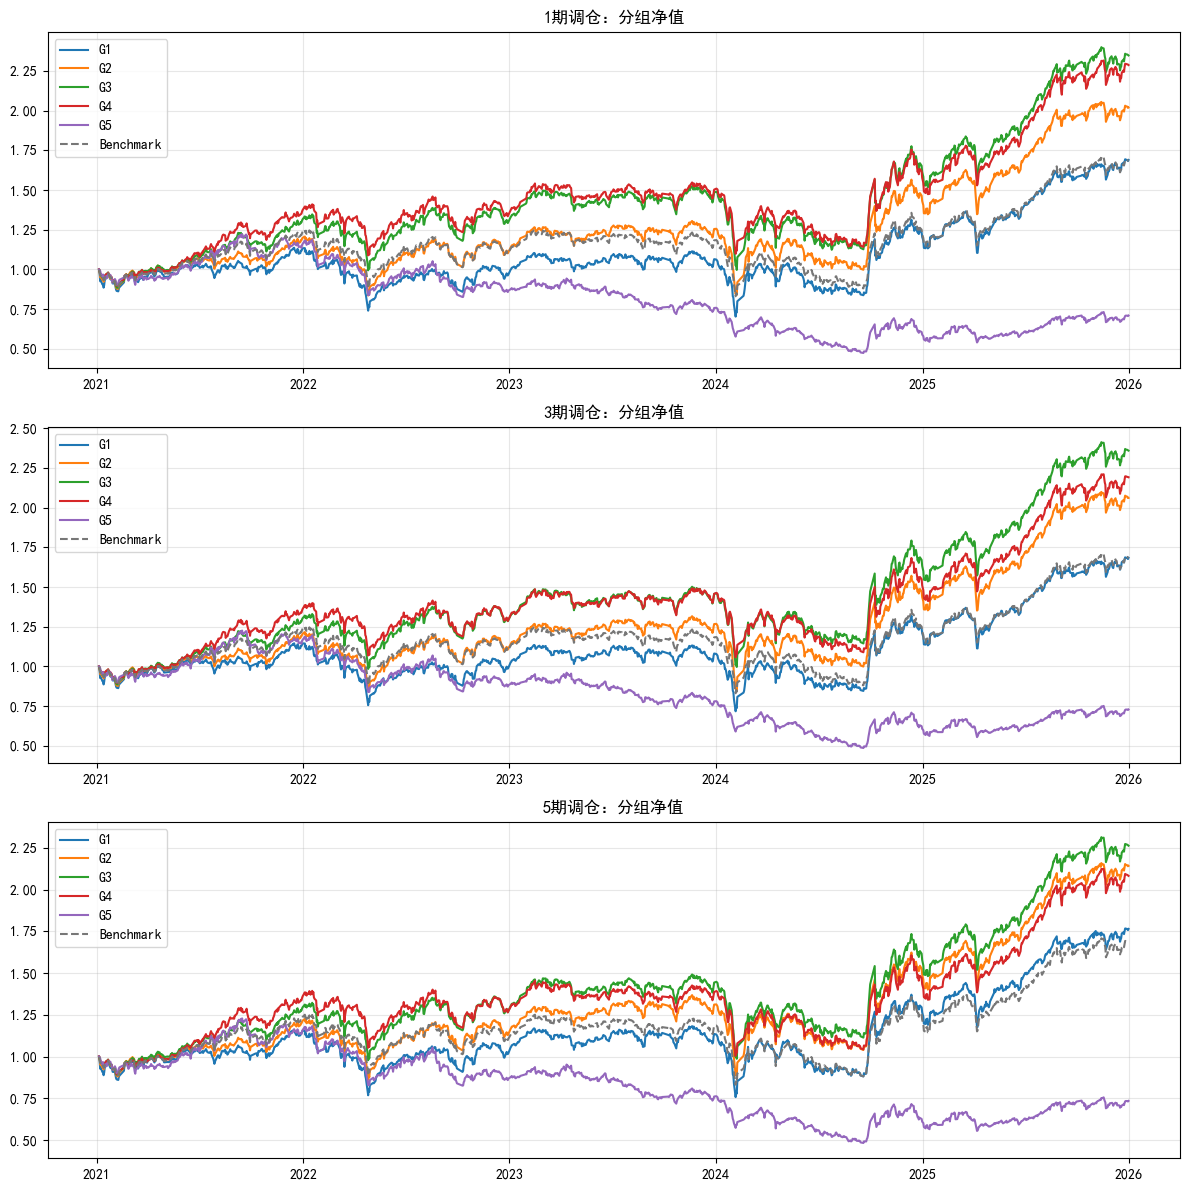

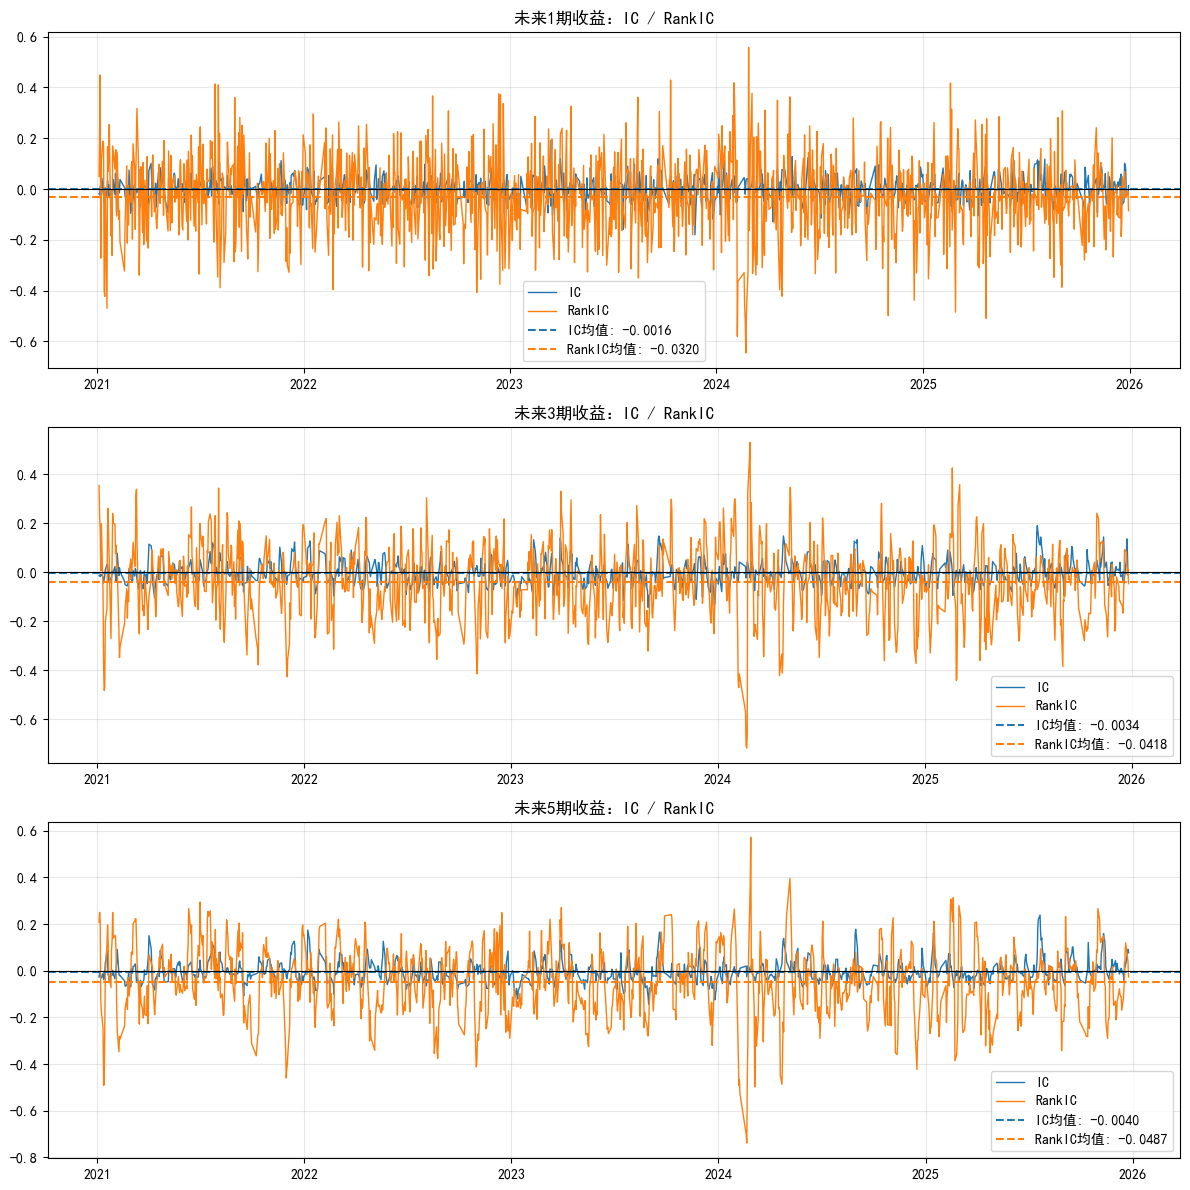

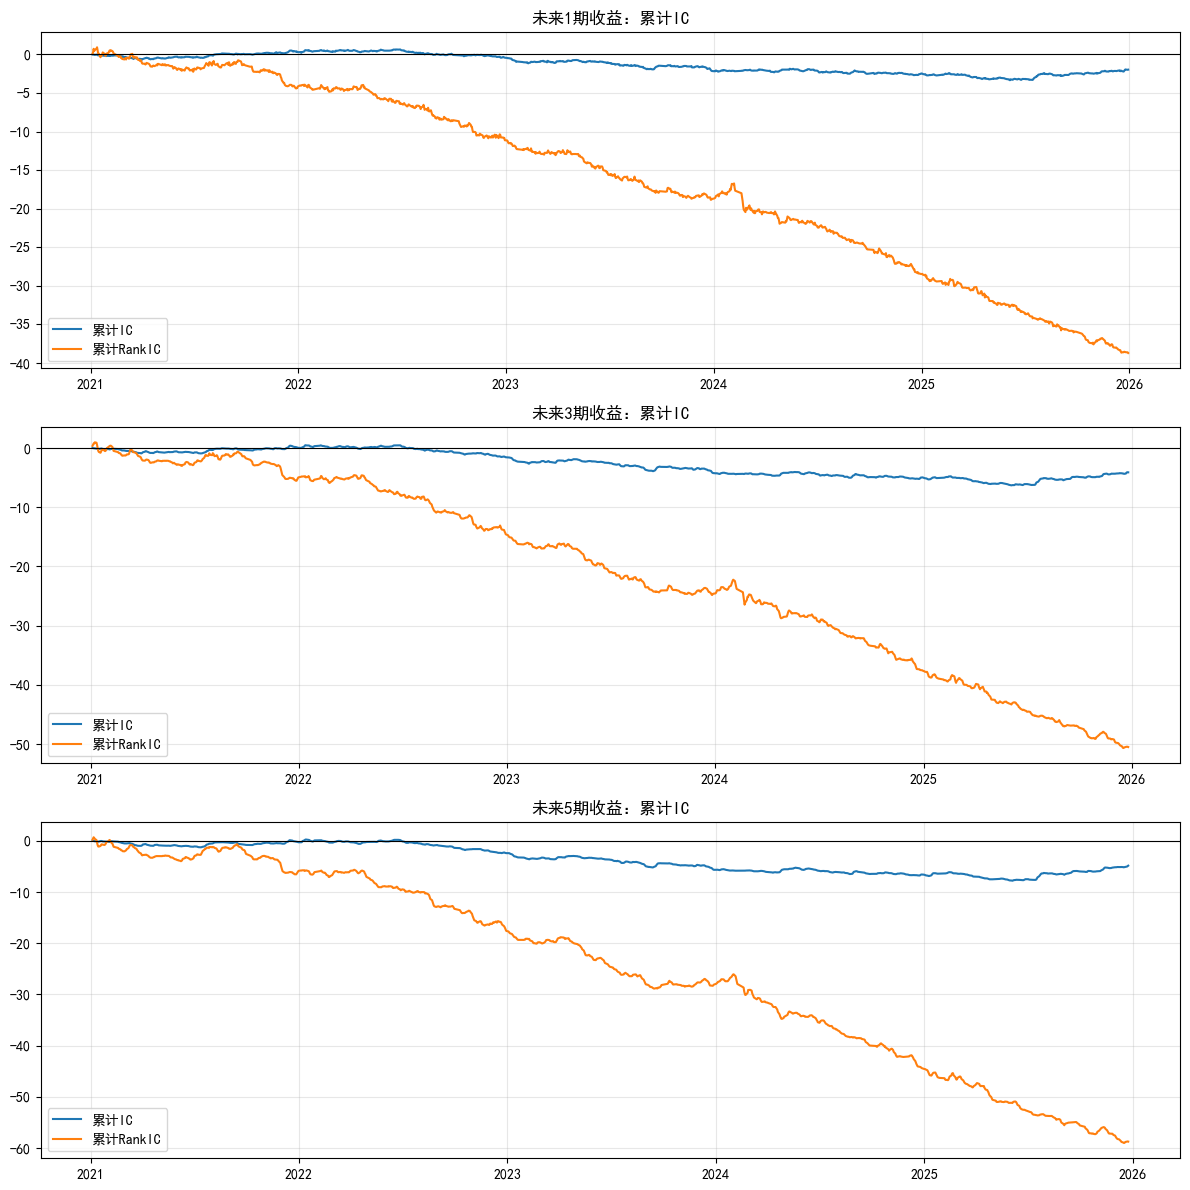

{'示例代码版': {'ic_stats': shape: (3, 9)
  ┌────────┬───────────┬──────────┬────────────┬───┬────────────┬────────────┬───────────┬───────────┐
  │ window ┆ ic_mean   ┆ ic_std   ┆ ic_positiv ┆ … ┆ rank_ic_st ┆ rank_ic_po ┆ ic_ir     ┆ rank_ic_i │
  │ ---    ┆ ---       ┆ ---      ┆ e_ratio    ┆   ┆ d          ┆ sitive_rat ┆ ---       ┆ r         │
  │ i32    ┆ f64       ┆ f64      ┆ ---        ┆   ┆ ---        ┆ io         ┆ f64       ┆ ---       │
  │        ┆           ┆          ┆ f64        ┆   ┆ f64        ┆ ---        ┆           ┆ f64       │
  │        ┆           ┆          ┆            ┆   ┆            ┆ f64        ┆           ┆           │
  ╞════════╪═══════════╪══════════╪════════════╪═══╪════════════╪════════════╪═══════════╪═══════════╡
  │ 1      ┆ -0.001532 ┆ 0.046776 ┆ 0.474814   ┆ … ┆ 0.158099   ┆ 0.393889   ┆ -0.032757 ┆ -0.207526 │
  │ 3      ┆ -0.003838 ┆ 0.047236 ┆ 0.411084   ┆ … ┆ 0.14908    ┆ 0.396195   ┆ -0.081255 ┆ -0.283903 │
  │ 5      ┆ -0.004278 ┆ 0.046961 ┆ 

In [3]:
factor_columns = {
    '示例代码版': 'momentum_score',
    '63日半衰期版': 'momentum_score_halflife',
}
factor_results = {}

for factor_name, factor_col in factor_columns.items():
    print(f'\n===== {factor_name}：{factor_col} =====')
    factor_results[factor_name] = analyze_factor(
        data=analysis_data,
        factor_col=factor_col,
        ret_col='daily_ret',
        ret_windows=[1, 3, 5],
        ic_windows=[1, 3, 5],
        group_num=5,
        plot=True,
        save_result=False,
    )

{
    factor_name: {
        'ic_stats': result['ic_stats'],
        'group_stats': result['group_stats'],
    }
    for factor_name, result in factor_results.items()
}
